In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

sns.set_theme(style="darkgrid", context="talk")

# Exercises part I: SIS dynamics

## SIS dynamics with spontaneous infections

1) First, construct the master equation.

Assuming $n$ is the number of infectious individuals, $n \in \{0,1,\ldots,N\}$, so $S = N - n$, we enumerate possible transitions:

| Process                | Direction    | Rate             |
|------------------------|--------------|------------------|
| Contact infection      | n -> n+1     | β(N-n)n          |
| Spontaneous infection  | n -> n+1     | ε(N-n)           |
| Recovery               | n -> n-1     | αn               |

From this we can write the master equation as follows:

$
\frac{dP_n}{dt} = \alpha(n+1)P_{n+1} + (N-n+1)\bigl(\beta(n-1)+\epsilon\bigr)P_{n-1} - \bigl[\alpha n + (N-n)(\beta n + \epsilon)\bigr]P_n
$

2) Integrate the master equation over time to look at the behavior of the system for different values of the parameters. What happens if $N$ goes to one? What happens if $\beta$ or $\epsilon$ go to zero?

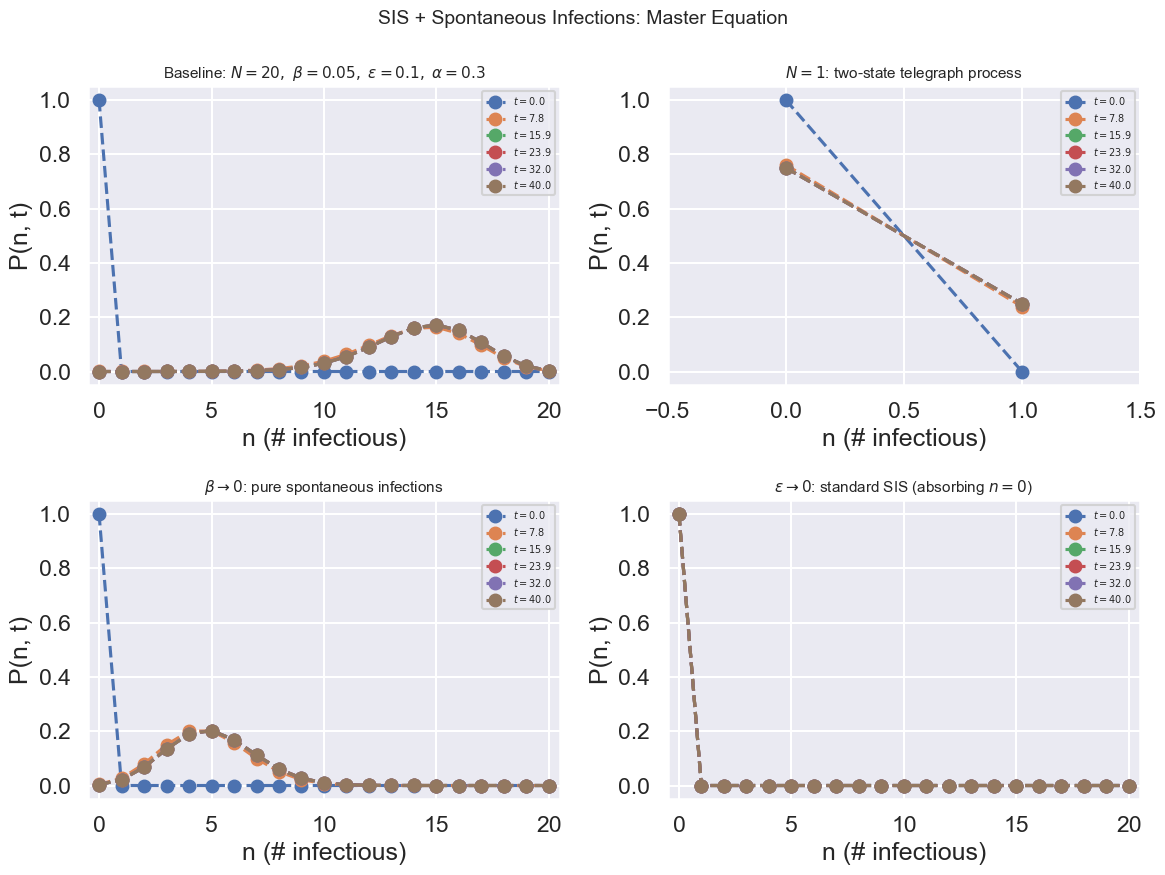

In [7]:
def sis_spontaneous(x, t, N, beta, epsilon, alpha):
    """
    Master equation for SIS dynamics with spontaneous infections.
    
        * x       : probability distribution over states (len = N+1)
        * t       : time (scalar)
        * N       : population size
        * beta    : contact infection rate
        * epsilon : spontaneous infection rate
        * alpha   : recovery rate
    """
    dx = 0 * x

    for n in range(N + 1):
        if n == 0:  # left boundary: no recovery possible, no P_{-1}
            rate_up = N * epsilon                        # (N-0)(β·0 + ε)
            dx[n] = -rate_up * x[0] + alpha * 1 * x[1]

        elif n == N:  # right boundary: no infection possible, no P_{N+1}
            rate_down = alpha * N                        # all N infected can recover
            dx[n] = -rate_down * x[N] + (N - (N-1)) * (beta * (N-1) + epsilon) * x[N-1]

        else:  # interior: all four arrows present
            rate_up   = (N - n) * (beta * n + epsilon)  # n -> n+1
            rate_down = alpha * n                        # n -> n-1
            dx[n] = (- (rate_up + rate_down) * x[n]
                     + alpha * (n + 1) * x[n + 1]
                     + (N - (n-1)) * (beta * (n-1) + epsilon) * x[n - 1])

    return dx


# ── Shared settings ──────────────────────────────────────────────────────────
t_vec = np.linspace(0, 40, 200)

def run_and_plot(ax, N, beta, epsilon, alpha, title):
    """Integrate and plot P_n(t) for a given parameter set."""
    x_0 = np.zeros(N + 1)
    x_0[0] = 1.0  # start fully susceptible

    rhs = lambda x, t: sis_spontaneous(x, t, N, beta, epsilon, alpha)
    x_path = odeint(rhs, x_0, t_vec)

    # Plot a few time snapshots
    snapshot_indices = np.linspace(0, len(t_vec) - 1, 6, dtype=int)
    for i in snapshot_indices:
        ax.plot(range(N + 1), x_path[i], marker='o', ls='--',
                label=fr"$t={t_vec[i]:.1f}$")

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('n (# infectious)')
    ax.set_ylabel('P(n, t)')
    ax.legend(fontsize=7)
    ax.set_xlim(-0.5, N + 0.5)


# ── Parameter scenarios ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('SIS + Spontaneous Infections: Master Equation', fontsize=14)

# Baseline
run_and_plot(axes[0, 0], N=20, beta=0.05, epsilon=0.1, alpha=0.3,
             title=r'Baseline: $N=20,\ \beta=0.05,\ \epsilon=0.1,\ \alpha=0.3$')

# N -> 1 (trivial system: only states 0 and 1)
run_and_plot(axes[0, 1], N=1,  beta=0.05, epsilon=0.1, alpha=0.3,
             title=r'$N = 1$: two-state telegraph process')

# beta -> 0 (only spontaneous infections drive spread)
run_and_plot(axes[1, 0], N=20, beta=0.0,  epsilon=0.1, alpha=0.3,
             title=r'$\beta \to 0$: pure spontaneous infections')

# epsilon -> 0 (standard SIS — n=0 becomes absorbing again)
run_and_plot(axes[1, 1], N=20, beta=0.05, epsilon=0.0, alpha=0.3,
             title=r'$\epsilon \to 0$: standard SIS (absorbing $n=0$)')

plt.tight_layout()
plt.savefig('sis_spontaneous.png', dpi=150)
plt.show()